In [79]:
import json
from glob import glob
import pandas as pd
from tqdm import tqdm

from FairEval import compare_spans, precision, recall
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import tol_colors as tc


In [80]:
LANGUAGES = {
    "asfalda": "fr",
    "cfn": "zh",
    "dutchframenet": "nl",
    "frame-squared-pt": "pt",
    "framenet_v17": "en",
    "iframe": "it",
    "koreanframenet": "ko",
    "latvianframenet": "lv",
    "salsa": "de",
    "swefn": "sv",
    "polish": "po",
}

FLAG_EMOJI = {
    "DE": r"\emoji{flag-germany}",
    "EN": r"\emoji{flag-united-kingdom}",
    "FR": r"\emoji{flag-france}",
    "IT": r"\emoji{flag-italy}",
    "KO": r"\emoji{flag-south-korea}",
    "LV": r"\emoji{flag-latvia}",
    "NL": r"\emoji{flag-netherlands}",
    "PT": r"\emoji{flag-brazil}",
    "SV": r"\emoji{flag-sweden}",
    "ZH": r"\emoji{flag-china}",
    "total": r"\emoji{world-map}",
}

In [157]:
df = pd.read_csv("baselines/in-domain/metrics.csv", index_col=0)
df["lang"] = df.model.apply(lambda s: s.split("/")[-1].split(".")[0]).map(LANGUAGES).str.upper()
#df["lang"] = df.model.apply(lambda s: s.split("/")[-1].split(".")[0]).str.upper()
df["model"] = df.model.apply(lambda s: s.split("/")[-2])
df["dataset"] = df.model.apply(lambda s: s.split("-")[-1]).map({"framenet_v17": "BFN", "all": "mFNC"})
df["model"] = df.model.apply(lambda s: "-".join(s.split("-")[:-1])).map({
    "lome": "LOME",
    "mt5-small": "mT5-sm",
    "mt5-base": "mT5",
})
df["flag"] = df.lang.map(FLAG_EMOJI)

Overview on FairEval

In [72]:
fair_metrics_cols = ['fair_frame_p', 'fair_frame_r', 'fair_frame_f1', 'fair_role_p', 'fair_role_r', 'fair_role_f1',]

In [73]:
df_overview = df.loc[:, ["model", "dataset"] + fair_metrics_cols].groupby(["model", "dataset"]).agg(lambda v: f"{v.mean():.3f} {v.std():.3f}")
df_overview.columns = pd.MultiIndex.from_tuples([
    ('Frame', 'P'),
    ('Frame', 'R'),
    ('Frame', 'F1'),
    ('Role',  'P'),
    ('Role',  'R'),
    ('Role',  'F1'),
])

df_overview.columns = pd.MultiIndex.from_tuples(
    [(task, metric)
     for task, metric in df_overview.columns],
    names=["task", "metric"]
)

df_overview = df_overview.sort_index(axis=1, level=['task', 'metric'])

df_overview = df_overview.reindex(columns=pd.MultiIndex.from_product(
    [['Frame', 'Role'], ['P', 'R', 'F1']],
    names=['task', 'metric']
))

task                  Frame                                   Role  \
metric                    P            R           F1            P   
model  dataset                                                       
LOME   BFN      0.247 0.226  0.598 0.219  0.318 0.221  0.154 0.179   
       mFNC     0.766 0.108  0.649 0.204  0.690 0.153  0.610 0.152   
mT5    BFN      0.139 0.147  0.427 0.193  0.187 0.155  0.077 0.099   
       mFNC     0.526 0.123  0.570 0.128  0.546 0.122  0.399 0.129   
mT5-sm BFN      0.114 0.120  0.370 0.168  0.156 0.134  0.060 0.082   
       mFNC     0.586 0.136  0.600 0.143  0.592 0.138  0.423 0.134   

task                                      
metric                    R           F1  
model  dataset                            
LOME   BFN      0.327 0.197  0.189 0.181  
       mFNC     0.537 0.179  0.564 0.155  
mT5    BFN      0.192 0.131  0.098 0.105  
       mFNC     0.408 0.128  0.404 0.128  
mT5-sm BFN      0.147 0.102  0.077 0.090  
       mFNC     0.421 0.136  0.422 0.134

In [68]:
for col in df_overview.columns:
    val = df_overview[col].map(lambda v: float(v.split()[0]))
    
    bold_mask = val == val.max()
    underline_mask = val == val.groupby(level='model').transform('max')

    for idx in df_overview.index:
        mean, std = map(float, df_overview.loc[idx, col].split())
        s_mean = f"{mean:.2f}"
        if underline_mask.loc[idx]:
            s_mean = f"\\underline{{{s_mean}}}"
        if bold_mask.loc[idx]:
            s_mean = f"\\textbf{{{s_mean}}}"
        
        if str(std) != "nan":
            df_overview.loc[idx, col] = f"{s_mean} {{ \\tiny $\\pm$ {std:.2f} }}"
        else:
            df_overview.loc[idx, col] = f"{s_mean}"

In [69]:
df_overview

task                                                     Frame  \
metric                                                       P   
model  dataset                                                   
LOME   BFN                           0.25 { \tiny $\pm$ 0.23 }   
       mFNC     \textbf{\underline{0.77}} { \tiny $\pm$ 0.11 }   
mT5    BFN                           0.14 { \tiny $\pm$ 0.15 }   
       mFNC              \underline{0.53} { \tiny $\pm$ 0.12 }   
mT5-sm BFN                           0.11 { \tiny $\pm$ 0.12 }   
       mFNC              \underline{0.59} { \tiny $\pm$ 0.14 }   

task                                                            \
metric                                                       R   
model  dataset                                                   
LOME   BFN                           0.60 { \tiny $\pm$ 0.22 }   
       mFNC     \textbf{\underline{0.65}} { \tiny $\pm$ 0.20 }   
mT5    BFN                           0.43 { \tiny $\pm$ 0.19 }   
       mFNC              \underline{0.57} { \tiny $\pm$ 0.13 }   
mT5-sm BFN                           0.37 { \tiny $\pm$ 0.17 }   
       mFNC              \underline{0.60} { \tiny $\pm$ 0.14 }   

task                                                            \
metric                                                      F1   
model  dataset                                                   
LOME   BFN                           0.32 { \tiny $\pm$ 0.22 }   
       mFNC     \textbf{\underline{0.69}} { \tiny $\pm$ 0.15 }   
mT5    BFN                           0.19 { \tiny $\pm$ 0.15 }   
       mFNC              \underline{0.55} { \tiny $\pm$ 0.12 }   
mT5-sm BFN                           0.16 { \tiny $\pm$ 0.13 }   
       mFNC              \underline{0.59} { \tiny $\pm$ 0.14 }   

task                                                      Role  \
metric                                                       P   
model  dataset                                                   
LOME   BFN                           0.15 { \tiny $\pm$ 0.18 }   
       mFNC     \textbf{\underline{0.61}} { \tiny $\pm$ 0.15 }   
mT5    BFN                           0.08 { \tiny $\pm$ 0.10 }   
       mFNC              \underline{0.40} { \tiny $\pm$ 0.13 }   
mT5-sm BFN                           0.06 { \tiny $\pm$ 0.08 }   
       mFNC              \underline{0.42} { \tiny $\pm$ 0.13 }   

task                                                            \
metric                                                       R   
model  dataset                                                   
LOME   BFN                           0.33 { \tiny $\pm$ 0.20 }   
       mFNC     \textbf{\underline{0.54}} { \tiny $\pm$ 0.18 }   
mT5    BFN                           0.19 { \tiny $\pm$ 0.13 }   
       mFNC              \underline{0.41} { \tiny $\pm$ 0.13 }   
mT5-sm BFN                           0.15 { \tiny $\pm$ 0.10 }   
       mFNC              \underline{0.42} { \tiny $\pm$ 0.14 }   

task                                                            
metric                                                      F1  
model  dataset                                                  
LOME   BFN                           0.19 { \tiny $\pm$ 0.18 }  
       mFNC     \textbf{\underline{0.56}} { \tiny $\pm$ 0.15 }  
mT5    BFN                           0.10 { \tiny $\pm$ 0.10 }  
       mFNC              \underline{0.40} { \tiny $\pm$ 0.13 }  
mT5-sm BFN                           0.08 { \tiny $\pm$ 0.09 }  
       mFNC              \underline{0.42} { \tiny $\pm$ 0.13 }

In [64]:
latex_s = df_overview.transpose().to_latex() \
    .replace("\\cline", "\\cmidrule") \
    .replace("\\cline{1-16} \\cline{2-16} \\cline{3-16}", "\\midrule") \
    .replace("\\multirow[t]", "\\multirow[c]")

print(latex_s)

\begin{tabular}{llll}
\toprule
 & model & \multicolumn{2}{r}{LOME} \\
 & dataset & BFN & mFNC \\
task & metric &  &  \\
\midrule
\multirow[c]{3}{*}{Frame} & P & 0.07 & \textbf{\underline{0.30}} \\
 & R & 0.26 & \textbf{\underline{0.28}} \\
 & F1 & 0.11 & \textbf{\underline{0.29}} \\
\cmidrule{1-4}
\multirow[c]{3}{*}{Role} & P & 0.04 & \textbf{\underline{0.20}} \\
 & R & \textbf{\underline{0.20}} & 0.20 \\
 & F1 & 0.07 & \textbf{\underline{0.20}} \\
\cmidrule{1-4}
\bottomrule
\end{tabular}



Show the influence of training on multilingual

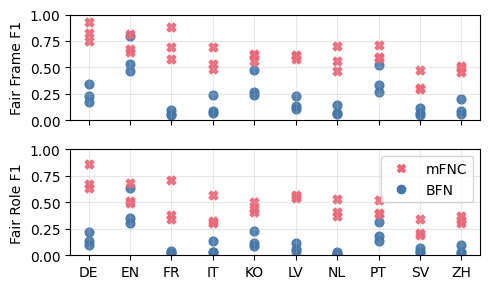

In [53]:
fig, axs = plt.subplots(2, 1, figsize=(5, 3))

graph_df = df[["lang", "model", "dataset", "fair_frame_f1", "fair_role_f1"]]
graph_df = graph_df.sort_values(["lang", "dataset", "model"])
languages = graph_df.lang.unique().tolist()

for m, ax in zip(["fair_frame_f1", "fair_role_f1"], axs.flatten()):
    for lang, group in graph_df.groupby("lang"):
        for _, row in group.iterrows():
            color = tc.bright.red if row.dataset == "mFNC" else tc.bright.blue
            marker = "X" if row.dataset == "mFNC" else "o"
            ax.scatter(languages.index(lang), row[m], c=color, marker=marker, s=40, alpha=0.9)
    ax.grid(alpha=0.3)
    ax.set_xticks(list(range(len(languages))), labels=[])
    ax.set_yticks(np.linspace(0, 1, 5))
    ax.set_ylim(0, 1)

axs[0].set_ylabel("Fair Frame F1")
axs[1].set_ylabel("Fair Role F1")

axs[-1].set_xticks(list(range(len(languages))), labels=languages)
ax.legend(handles=[
    mpl.lines.Line2D([0], [0], label='mFNC', color=tc.bright.red, marker='X', linestyle=''),
    mpl.lines.Line2D([0], [0], label='BFN', color=tc.bright.blue, marker='o', linestyle=''),
])
ax.set_ylabel("Fair Role F1")

fig.tight_layout()
fig.savefig("figures/trained_on_dataset.pdf", bbox_inches = "tight", dpi=600)

plt.show()

Detailed for each language

In [162]:
detail_df = df.sort_values(["lang", "model"]).set_index(["lang", "flag", "model", "dataset"]).iloc[:, :-2]
detail_df = detail_df.loc[:, fair_metrics_cols]
detail_df.columns = pd.MultiIndex.from_tuples([
    ('Frame', 'P'),
    ('Frame', 'R'),
    ('Frame', 'F1'),
    ('Role',  'P'),
    ('Role',  'R'),
    ('Role',  'F1'),
])

for col in detail_df.columns:
    val = detail_df[col]
    bold_mask = val == val.groupby(level=["lang", "model"]).transform("max")
    detail_df[col] = detail_df.loc[:, col].astype(str)
    for idx in detail_df.index:
        v = float(detail_df.loc[idx, col])
        if bold_mask.loc[idx]:
            detail_df.loc[idx, col] = f"\\textbf{{{v:.3f}}}"
        else:
            detail_df.loc[idx, col] = f"{v:.3f}"

detail_df

Frame  \
                                                              P   
lang flag                        model  dataset                   
DE   \emoji{flag-germany}        LOME   BFN               0.217   
                                        mFNC     \textbf{0.925}   
                                 mT5    BFN               0.136   
                                        mFNC     \textbf{0.748}   
                                 mT5-sm BFN               0.101   
                                        mFNC     \textbf{0.833}   
EN   \emoji{flag-united-kingdom} LOME   BFN               0.744   
                                        mFNC     \textbf{0.785}   
                                 mT5    BFN               0.466   
                                        mFNC     \textbf{0.614}   
                                 mT5-sm BFN               0.382   
                                        mFNC     \textbf{0.642}   
FR   \emoji{flag-france}         LOME   BFN               0.059   
                                        mFNC     \textbf{0.874}   
                                 mT5    BFN               0.031   
                                        mFNC     \textbf{0.580}   
                                 mT5-sm BFN               0.033   
                                        mFNC     \textbf{0.704}   
IT   \emoji{flag-italy}          LOME   BFN               0.142   
                                        mFNC     \textbf{0.700}   
                                 mT5    BFN               0.051   
                                        mFNC     \textbf{0.438}   
                                 mT5-sm BFN               0.041   
                                        mFNC     \textbf{0.530}   
KO   \emoji{flag-south-korea}    LOME   BFN               0.364   
                                        mFNC     \textbf{0.791}   
                                 mT5    BFN               0.176   
                                        mFNC     \textbf{0.495}   
                                 mT5-sm BFN               0.155   
                                        mFNC     \textbf{0.585}   
LV   \emoji{flag-latvia}         LOME   BFN               0.135   
                                        mFNC     \textbf{0.855}   
                                 mT5    BFN               0.076   
                                        mFNC     \textbf{0.612}   
                                 mT5-sm BFN               0.061   
                                        mFNC     \textbf{0.619}   
NL   \emoji{flag-netherlands}    LOME   BFN               0.088   
                                        mFNC     \textbf{0.752}   
                                 mT5    BFN               0.042   
                                        mFNC     \textbf{0.446}   
                                 mT5-sm BFN               0.034   
                                        mFNC     \textbf{0.570}   
PT   \emoji{flag-brazil}         LOME   BFN               0.515   
                                        mFNC     \textbf{0.688}   
                                 mT5    BFN               0.326   
                                        mFNC     \textbf{0.574}   
                                 mT5-sm BFN               0.262   
                                        mFNC     \textbf{0.561}   
SV   \emoji{flag-sweden}         LOME   BFN               0.072   
                                        mFNC     \textbf{0.545}   
                                 mT5    BFN               0.041   
                                        mFNC     \textbf{0.318}   
                                 mT5-sm BFN               0.033   
                                        mFNC     \textbf{0.304}   
ZH   \emoji{flag-china}          LOME   BFN               0.135   
                                        mFNC     \textbf{0.747}   
                                 mT5    BFN               0.049   
                                      

In [151]:
detail_df

task                                            frame         role        
metric                                              p   r  f1    p   r  f1
lang flag                        model  dataset                           
DE   \emoji{flag-germany}        LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
EN   \emoji{flag-united-kingdom} LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
FR   \emoji{flag-france}         LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
IT   \emoji{flag-italy}          LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
KO   \emoji{flag-south-korea}    LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
LV   \emoji{flag-latvia}         LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
NL   \emoji{flag-netherlands}    LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
PT   \emoji{flag-brazil}         LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5    BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                                 mT5-sm BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
SV   \emoji{flag-sweden}         LOME   BFN       NaN NaN NaN  NaN NaN NaN
                                        mFNC      NaN NaN NaN  NaN NaN NaN
                         

In [163]:
print(detail_df.to_latex())

\begin{tabular}{llllllllll}
\toprule
 &  &  &  & \multicolumn{3}{r}{Frame} & \multicolumn{3}{r}{Role} \\
 &  &  &  & P & R & F1 & P & R & F1 \\
lang & flag & model & dataset &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{DE} & \multirow[t]{6}{*}{\emoji{flag-germany}} & \multirow[t]{2}{*}{LOME} & BFN & 0.217 & 0.853 & 0.346 & 0.139 & 0.587 & 0.224 \\
 &  &  & mFNC & \textbf{0.925} & \textbf{0.929} & \textbf{0.927} & \textbf{0.859} & \textbf{0.859} & \textbf{0.859} \\
\cline{3-10}
 &  & \multirow[t]{2}{*}{mT5} & BFN & 0.136 & 0.706 & 0.228 & 0.079 & 0.382 & 0.131 \\
 &  &  & mFNC & \textbf{0.748} & \textbf{0.749} & \textbf{0.748} & \textbf{0.632} & \textbf{0.636} & \textbf{0.634} \\
\cline{3-10}
 &  & \multirow[t]{2}{*}{mT5-sm} & BFN & 0.101 & 0.583 & 0.172 & 0.057 & 0.268 & 0.094 \\
 &  &  & mFNC & \textbf{0.833} & \textbf{0.823} & \textbf{0.828} & \textbf{0.678} & \textbf{0.676} & \textbf{0.677} \\
\cline{1-10} \cline{2-10} \cline{3-10}
\multirow[t]{6}{*}{EN} & \multirow[t]{6}{*}{\em

In [98]:
print(detail_df.to_latex(float_format="%.3f"))

\begin{tabular}{llllrrrrrrrrrrrr}
\toprule
 &  &  & task & \multicolumn{6}{r}{frame} & \multicolumn{6}{r}{role} \\
 &  &  & metric & \multicolumn{2}{r}{p} & \multicolumn{2}{r}{r} & \multicolumn{2}{r}{f1} & \multicolumn{2}{r}{p} & \multicolumn{2}{r}{r} & \multicolumn{2}{r}{f1} \\
 &  &  & eval & traditional & fair & traditional & fair & traditional & fair & traditional & fair & traditional & fair & traditional & fair \\
lang & flag & model & dataset &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{DE} & \multirow[t]{6}{*}{\emoji{flag-germany}} & \multirow[t]{2}{*}{LOME} & BFN & 0.263 & 0.217 & 0.816 & 0.853 & 0.397 & 0.346 & 0.144 & 0.139 & 0.491 & 0.587 & 0.222 & 0.224 \\
 &  &  & mFNC & 0.944 & 0.925 & 0.915 & 0.929 & 0.929 & 0.927 & 0.810 & 0.859 & 0.789 & 0.859 & 0.799 & 0.859 \\
\cline{3-16}
 &  & \multirow[t]{2}{*}{mT5} & BFN & 0.193 & 0.136 & 0.696 & 0.706 & 0.302 & 0.228 & 0.091 & 0.079 & 0.356 & 0.382 & 0.144 & 0.131 \\
 &  &  & mFNC & 0.831 & 0.748 & 0.789 & 

In [375]:
result = df.copy().astype(object)

for col in df.columns:
    bold_mask = df[col] == df[col].groupby(level='lang').transform('max')
    underline_mask = df[col] == df[col].groupby(level=['lang', 'model']).transform('max')
    
    for idx in df.index:
        s = f"{df.loc[idx, col]:.2f}"
        if underline_mask.loc[idx]:
            s = f"\\underline{{{s}}}"
        if bold_mask.loc[idx]:
            s = f"\\textbf{{{s}}}"
        result.loc[idx, col] = s

In [376]:
latex_s = result.to_latex() \
    .replace("\\cline", "\\cmidrule") \
    .replace("\\cline{1-16} \\cline{2-16} \\cline{3-16}", "\\midrule") \
    .replace("\\multirow[t]", "\\multirow[c]")

print(result.to_latex())

\begin{tabular}{llllllllllllllllllll}
\toprule
 &  &  &  & traditional_frame_p & traditional_frame_r & traditional_frame_f1 & traditional_role_p & traditional_role_r & traditional_role_f1 & fair_frame_p & fair_frame_r & fair_frame_f1 & fair_role_p & fair_role_r & fair_role_f1 & Unnamed: 0.4 & Unnamed: 0.3 & Unnamed: 0.2 & Unnamed: 0.1 \\
lang & flag & model & dataset &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{DE} & \multirow[t]{6}{*}{\emoji{flag-germany}} & \multirow[t]{2}{*}{LOME} & BFN & 0.30 & 0.84 & 0.45 & 0.17 & 0.49 & 0.25 & 0.26 & 0.84 & 0.39 & 0.16 & 0.56 & 0.25 & 44.00 & 34.00 & 24.00 & 4.00 \\
 &  &  & mFNC & \textbf{\underline{0.94}} & \textbf{\underline{0.93}} & \textbf{\underline{0.94}} & \textbf{\underline{0.81}} & \textbf{\underline{0.80}} & \textbf{\underline{0.81}} & \textbf{\underline{0.93}} & \textbf{\underline{0.94}} & \textbf{\underline{0.93}} & \textbf{\underline{0.87}} & \textbf{\underline{0.87}} & \textbf{\underline{0.87}} & \

Traditional

In [54]:
traditional_metrics_cols = ['target_identification_accuracy', 'traditional_frame_p', 'traditional_frame_r', 'traditional_frame_f1', 'traditional_role_p', 'traditional_role_r', 'traditional_role_f1',]
df_overview = df.loc[:, ["model", "dataset", "lang",] + traditional_metrics_cols]
df_overview = df_overview[df_overview.lang == "EN"]
df_overview

,model,dataset,lang,target_identification_accuracy,traditional_frame_p,traditional_frame_r,traditional_frame_f1,traditional_role_p,traditional_role_r,traditional_role_f1
8,mT5,BFN,EN,NaN,0.584734,0.581641,0.583184,0.302832,0.310110,0.306428
18,mT5,mFNC,EN,NaN,0.663581,0.672752,0.668135,0.416592,0.409458,0.412994
28,mT5-sm,BFN,EN,NaN,0.561151,0.558949,0.560048,0.275482,0.284811,0.280069
38,mT5-sm,mFNC,EN,NaN,0.677911,0.675482,0.676694,0.418975,0.415102,0.417029
8,LOME,BFN,EN,0.996417,0.788255,0.813001,0.800437,0.524092,0.585288,0.553002
18,LOME,mFNC,EN,0.980038,0.802028,0.823238,0.812495,0.579961,0.615063,0.596997


,model,dataset,lang,traditional_frame_accuracy,traditional_frame_p,traditional_frame_r,traditional_frame_f1,traditional_role_p,traditional_role_r,traditional_role_f1
8,LOME,BFN,EN,0.813001,0.788255,0.813001,0.800437,0.524092,0.585288,0.553002
18,LOME,mFNC,EN,0.823238,0.802028,0.823238,0.812495,0.579961,0.615063,0.596997


In [27]:
df_overview[df_overview.lang == "EN"]

AttributeError: 'DataFrame' object has no attribute 'lang'